In [ ]:

from pydantic_ai import Agent, ModelRetry, RunContext, format_as_xml

SQL_EXAMPLES = [
    {
        'request': 'show me records where foobar is false',
        'response': "SELECT * FROM records WHERE attributes->>'foobar' = false",
    },
    {
        'request': 'show me records where attributes include the key "foobar"',
        'response': "SELECT * FROM records WHERE attributes ? 'foobar'",
    },
    {
        'request': 'show me records from yesterday',
        'response': "SELECT * FROM records WHERE start_timestamp::date > CURRENT_TIMESTAMP - INTERVAL '1 day'",
    },
    {
        'request': 'show me error records with the tag "foobar"',
        'response': "SELECT * FROM records WHERE level = 'error' and 'foobar' = ANY(tags)",
    },
]

print(format_as_xml(SQL_EXAMPLES))

<item>
  <request>show me records where foobar is false</request>
  <response>SELECT * FROM records WHERE attributes-&gt;&gt;'foobar' = false</response>
</item>
<item>
  <request>show me records where attributes include the key "foobar"</request>
  <response>SELECT * FROM records WHERE attributes ? 'foobar'</response>
</item>
<item>
  <request>show me records from yesterday</request>
  <response>SELECT * FROM records WHERE start_timestamp::date &gt; CURRENT_TIMESTAMP - INTERVAL '1 day'</response>
</item>
<item>
  <request>show me error records with the tag "foobar"</request>
  <response>SELECT * FROM records WHERE level = 'error' and 'foobar' = ANY(tags)</response>
</item>


In [2]:
from pydantic_ai import Agent
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.ollama import OllamaProvider
from nest_asyncio import apply
apply()

ollama_model = OpenAIChatModel(
    model_name="gemma3:1b",
    provider=OllamaProvider(base_url='http://localhost:11434/v1'),  
)

agent = Agent(ollama_model)

result = agent.run_sync('Where does "hello world" come from?')
print(result.output)
# """
# The first known use of "hello, world" was in a 1974 textbook about the C programming language.
# """

The "Hello, World!" program is a foundational example in programming, and its origin is surprisingly complex and tied to a game called *Tennis**. Here's the breakdown of where it comes from:

**1. The Tennis Game (1969):**

* **The Program's Creator:** The program was created by tennis club chairman Charles Lamar in 1969.
* **The Initial Goal:** Lamar's idea was to create a simple exercise to encourage people to visit his club and potentially try the tennis courts. He wanted to test the computers of the club's guests.
* **The First Version:** The first version of the program was a very minimal text file that simply displayed the text "Hello, World!" on the screen.  It was written in BASIC, a programming language that was popular at the time.

**2. Birth of the "Hello, World!" Legend:**

* **Early Use:** Lamar initially used the program as a test to ensure that computers were accessible to his club members. He even had simple versions available for different computers.
* **The Story:** 

### langchain using ollama local model

AttributeError: 'Agent' object has no attribute 'get_embeddings_sync'

In [23]:
from langchain_ollama import OllamaLLM, ChatOllama

llm = OllamaLLM(model="llama3.2")
# llm_ollama = ChatOllama(model="llama3.2")
llm_ollama = ChatOllama(model="nemotron-3-nano:4b")


In [2]:
from langchain_core.prompts import PromptTemplate

result = llm_ollama.invoke("Tell me a joke. Generate the output in key-value pair format with the following keys: setup, punchline")
print(result.content)

Here's a joke for you:

{
    "setup": "What do you call a fake noodle?",
    "punchline": "An impasta."
}


In [3]:
from pydantic import BaseModel, Field

class llm_schema(BaseModel):
    setup: str = Field(description="The setup for the joke")
    punchline: str = Field(description="The punchline for the joke")

In [4]:
llm_structured_output = llm_ollama.with_structured_output(llm_schema)

result = llm_structured_output.invoke("Tell me a joke")
result

llm_schema(setup='Why did the coffee file a police report?', punchline='It got mugged!')

In [5]:
# TOOL - 1 [News Search Tool]

from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun(description="This is a tool to search the web for news")


# TOOL - 2 [Wikipedia Search Tool]

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(),description="This is a tool to search Wikipedia")


# TOOL - 3 [Custom Enterprise Tool]

from langchain.tools import tool

@tool
def enterprise_tool(query:str)-> str:

    """This is a tool to send emails to employees"""
    
    return "Email Sent"
ToolKit = [search_tool, wikipedia_tool, enterprise_tool]
ToolKit

[DuckDuckGoSearchRun(description='This is a tool to search the web for news', api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(description='This is a tool to search Wikipedia', api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/Users/ervijay/Documents/Programs/Repo/GenAI/.venv/lib/python3.13/site-packages/wikipedia/__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 StructuredTool(name='enterprise_tool', description='This is a tool to send emails to employees', args_schema=<class 'langchain_core.utils.pydantic.enterprise_tool'>, func=<function enterprise_tool at 0x1109dfce0>)]

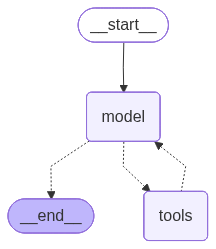

In [9]:
from langchain.agents import create_agent

model = ChatOllama(
    model="llama3.2",
    temperature=0.7,
    max_tokens=1000,
    timeout=30
)
agent = create_agent(model, tools=ToolKit)
agent

In [41]:
# example_query = "Give me the latest news about the indian stock market"
example_query = "Who is ErVijayraghuwanshi?"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Who is ErVijayraghuwanshi?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (eeff8964-7466-4671-9fc5-7632bf84788a)
 Call ID: eeff8964-7466-4671-9fc5-7632bf84788a
  Args:
    query: ErVijayraghuwanshi
================================= Tool Message =================================
Name: duckduckgo_search

I’m a Software Development Engineer with 3+ years of experience designing high-performance backend systems, data pipelines, and AI-driven applications at ClearTrail Technologies. My focus lies in...Jan 25, 2025 ·Vijay Raghuwanshi has completed 97% of MATLAB ...ErVijay Raghuwanshi. 221 likes. Breaking things at day and building at night.User profile ofVijay Raghuwanshion Hugging Face0 Followers, 207 Following, 7 Posts -ErVijay Raghuwanshi (@er.vijayraghuwanshi) on Instagram: ""Read more Find file Select Archive Format Clone Clone with SSH Clon

In [44]:
# Without Binding
llm_ollama.invoke("What's the latest news about the stock market?")


AIMessage(content="I can't provide real-time stock market news since my knowledge cutoff is July 2024 and I don't have live data access. For the most current market updates, I recommend checking:\n\n- **Financial news outlets**: Bloomberg, Reuters, CNBC, or Wall Street Journal  \n- **Market indices**: S&P 500, Nasdaq, or Dow Jones indices (which change daily)  \n- **Trading apps**: Yahoo Finance, Google Finance, or brokerage platforms like Robinhood or Fidelity  \n\n**What generally impacts the stock market** (as of mid-2024):  \n- U.S. interest rate decisions by the Federal Reserve  \n- Federal Reserve (Fed) inflation data  \n- U.S. economic reports (GDP, employment)  \n- Global events like elections or geopolitical conflicts  \n\nWould you like me to help analyze specific market trends or historical news up to mid-2024? For example, I could explain how interest rate trends affected tech stocks in 2024.", additional_kwargs={}, response_metadata={'model': 'nemotron-3-nano:4b', 'created

In [42]:

# With Binding
llm_binded = llm_ollama.bind_tools(ToolKit)
# resp = llm_binded.invoke("What's the latest news about the stock market?")
resp = llm_binded.invoke("Who is ErVijayraghuwanshi?")

In [43]:
resp.model_dump()

{'content': '',
 'additional_kwargs': {},
 'response_metadata': {'model': 'nemotron-3-nano:4b',
  'created_at': '2026-03-22T17:32:16.784583Z',
  'done': True,
  'done_reason': 'stop',
  'total_duration': 23494605500,
  'load_duration': 5193857375,
  'prompt_eval_count': 439,
  'prompt_eval_duration': 5031398500,
  'eval_count': 98,
  'eval_duration': 13146481000,
  'logprobs': None,
  'model_name': 'nemotron-3-nano:4b',
  'model_provider': 'ollama'},
 'type': 'ai',
 'name': None,
 'id': 'lc_run--019d169a-7042-7d22-9c6d-559a08f43e47-0',
 'tool_calls': [{'name': 'duckduckgo_search',
   'args': {'query': 'ErVijayraghu'},
   'id': 'f3c46ad5-8311-4a8c-b185-acf9e8301d98',
   'type': 'tool_call'}],
 'invalid_tool_calls': [],
 'usage_metadata': {'input_tokens': 439,
  'output_tokens': 98,
  'total_tokens': 537}}